# DVCS CFF fit results — replica ensemble (observable training), Farm run (100 replicas)

Same plots/printouts/comparisons as `CFF_plots_ALU_2007_xpow_replica.ipynb`, but reading
the 100-replica farm run instead of the 10-replica local run:
- Partons outputs: `My_Analysis/Partons_output/Farm/`
- Gepard outputs:  `Gepard_.../Partons_compare/Out_json/Farm/Json/`

Plots of `CFF_NN_Fitter`'s output CSVs (central fit) plus a Monte Carlo
replica ensemble (100 fits to smeared pseudodata,
`y_smeared = y_obs + N(0, sigma)`, same formula as Gepard's
`datasets_replica_vectloss`) for a CFF uncertainty band.

| File | Content |
|---|---|
| `cff_learning_curve.csv` | epoch, train χ²/n, val χ²/n (central fit) |
| `obs_prediction.csv` | `xB,t,Q2,E,phi,obs_true,obs_pred,error` per point (central fit) |
| `obs_model_eval.csv` | observable, mse, r_squared, chi2/n (central fit) |
| `cff_model.json` | central fit — weights + scaling + labels |
| `cff_model_replica_NN.json` | replica `NN` (00-99) — weights + scaling + labels |

**Note:** the farm run's `cff_learning_curve.csv` has thousands-separator commas
injected into epoch numbers ≥ 1000 by the farm environment's locale (e.g. a row reads
`1,864,0.148407,5.1031` — 4 comma-separated fields instead of 3, with the epoch itself
split across the first two). Not seen in local runs; `read_learning_curve()` below
detects and repairs it before parsing.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from io import StringIO

def read_learning_curve(path):
    """Read a cff_learning_curve.csv, repairing the farm run's thousands-separator
    commas in the epoch column (e.g. '1,864,0.148407,5.1031' -> epoch 1864). A normal
    3-field row is left untouched; a 4-field row has its first two fields rejoined."""
    with open(path) as f:
        header = f.readline().strip()
        fixed = []
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',')
            if len(parts) == 4:
                parts = [parts[0] + parts[1]] + parts[2:]
            fixed.append(','.join(parts))
    return pd.read_csv(StringIO(header + '\n' + '\n'.join(fixed)))

In [6]:
lc    = read_learning_curve('../Partons_output/Farm/cff_learning_curve.csv')
obs   = pd.read_csv('../Partons_output/Farm/obs_prediction.csv')
evald = pd.read_csv('../Partons_output/Farm/obs_model_eval.csv')

In [7]:
print("Model evaluation metrics (central fit, Farm)")
print("-" * 55)
for _, row in evald.iterrows():
    print(f"{row['observable']:>26s}  MSE = {row['mse']:.6g}  "
          f"R² = {row['r_squared']:.6g}  χ²/n = {row['chi2']:.6g}")

# Best validation loss reached during training (tracked every epoch by train_nn(),
# exported by predict()). Fall back to the learning-curve minimum (logged every
# 2 epochs) for cff_model.json files that predate the best_val_chi2 field.
with open('../Partons_output/Farm/cff_model.json') as f:
    best_val = json.load(f).get('best_val_chi2')
if best_val is None:
    best_val = lc['val_loss'].min()
    print(f"\nBest val χ²/n = {best_val:.6g}  (min of learning curve; not in cff_model.json)")
else:
    print(f"\nBest val χ²/n = {best_val:.6g}")

Model evaluation metrics (central fit, Farm)
-------------------------------------------------------
  DVCSAluMinusSin1PhiTorch  MSE = 0.000361675  R² = 0.684211  χ²/n = 1.24434

Best val χ²/n = 4.34912


## Training and validation loss (χ²/n) — central fit (Farm)

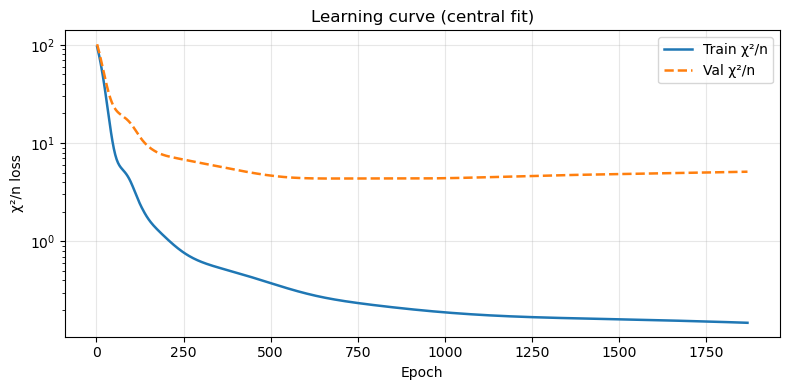

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(lc['epoch'], lc['train_loss'], label='Train χ²/n', linewidth=1.8)
ax.plot(lc['epoch'], lc['val_loss'],   label='Val χ²/n',   linewidth=1.8, linestyle='--')

ax.set_xlabel('Epoch')
ax.set_ylabel('χ²/n loss')
ax.set_yscale('log')
ax.set_title('Learning curve (central fit)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Predicted vs measured observable ($A_{LU}^{\sin 1\phi}$) — central fit

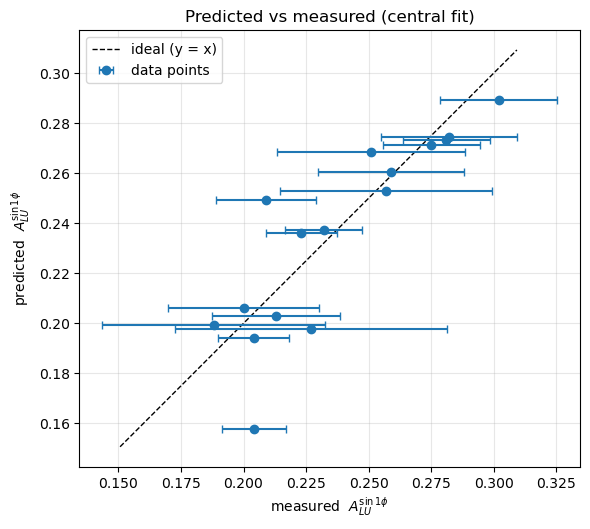

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.errorbar(obs['obs_true'], obs['obs_pred'], xerr=obs['error'], fmt='o',
            ms=6, capsize=3, zorder=3, label='data points')

lo = min(obs['obs_true'].min(), obs['obs_pred'].min())
hi = max(obs['obs_true'].max(), obs['obs_pred'].max())
pad = 0.05 * (hi - lo)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=1, label='ideal (y = x)')

ax.set_xlabel(r'measured  $A_{LU}^{\sin 1\phi}$')
ax.set_ylabel(r'predicted  $A_{LU}^{\sin 1\phi}$')
ax.set_title('Predicted vs measured (central fit)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', 'box')
fig.tight_layout()
plt.show()

## Residuals: $y_\mathrm{true} - y_\mathrm{pred}$ vs row — central fit

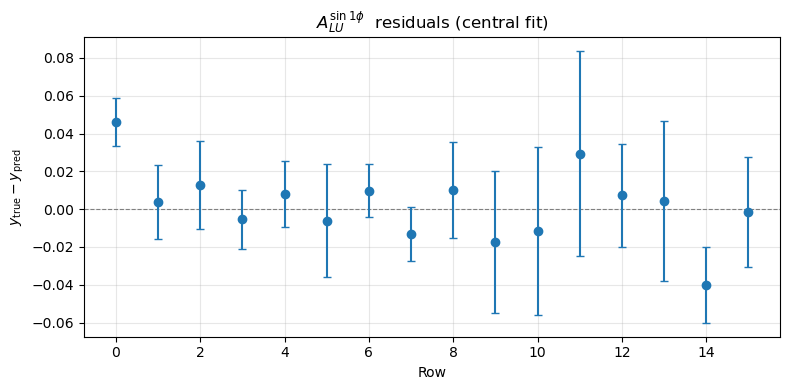

In [10]:
residuals = obs['obs_true'] - obs['obs_pred']

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.errorbar(obs.index, residuals, yerr=obs['error'], fmt='o', ms=6, capsize=3, zorder=3)
ax.set_xlabel('Row')
ax.set_ylabel(r'$y_{\mathrm{true}} - y_{\mathrm{pred}}$')
ax.set_title(r'$A_{LU}^{\sin 1\phi}$  residuals (central fit)')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Relative residuals: $(y_\mathrm{true} - y_\mathrm{pred}) / y_\mathrm{true}$ vs $y_\mathrm{true}$ — central fit

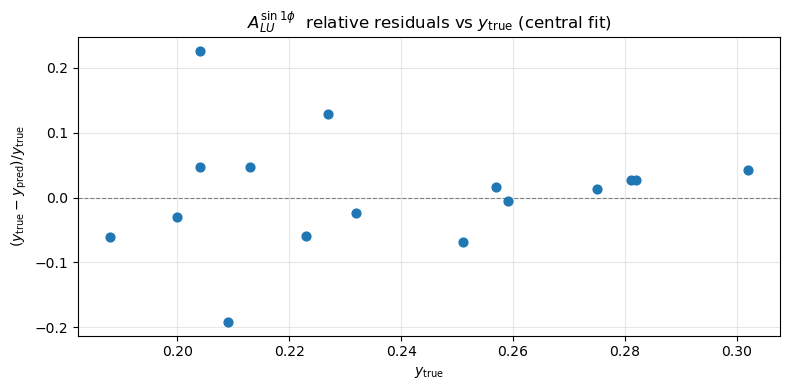

In [11]:
rel_residuals = (obs['obs_true'] - obs['obs_pred']) / obs['obs_true']

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.scatter(obs['obs_true'], rel_residuals, s=40, zorder=3)
ax.set_xlabel(r'$y_{\mathrm{true}}$')
ax.set_ylabel(r'$(y_{\mathrm{true}} - y_{\mathrm{pred}}) / y_{\mathrm{true}}$')
ax.set_title(r'$A_{LU}^{\sin 1\phi}$  relative residuals vs $y_{\mathrm{true}}$ (central fit)')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Pull distribution: $(y_\mathrm{true} - y_\mathrm{pred}) / \sigma$ — central fit

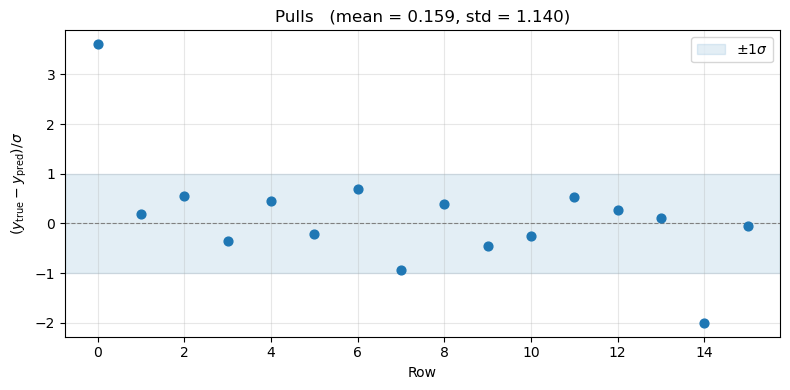

In [12]:
pulls = (obs['obs_true'] - obs['obs_pred']) / obs['error']

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axhspan(-1, 1, color='C0', alpha=0.12, label=r'$\pm 1\sigma$')
ax.scatter(obs.index, pulls, s=40, zorder=3)
ax.set_xlabel('Row')
ax.set_ylabel(r'$(y_{\mathrm{true}} - y_{\mathrm{pred}}) / \sigma$')
ax.set_title(f"Pulls   (mean = {pulls.mean():.3f}, std = {pulls.std():.3f})")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## CFF scans — replica ensemble mean ± σ band vs central fit (Farm, 100 replicas)

Loads `cff_model.json` (central fit) plus the 100 `cff_model_replica_NN.json`
files (Monte Carlo replicas fit to smeared pseudodata, farm run). Each is a plain NN
forward pass reproducing `DVCSCFFNNTorch::forwardNN()` exactly (float32,
per-model min-max scaling, then `CFF = xB^x_pow * NNet_output`) — same
`cff_forward`/`cff_scan` logic as the non-replica notebook, now parameterized
by which model's weights/scaling to use.

In [13]:
with open('../Partons_output/Farm/cff_model.json') as f:
    central_model = json.load(f)

N_REPLICAS = 100
replica_models = []
for i in range(N_REPLICAS):
    with open(f'../Partons_output/Farm/cff_model_replica_{i:02d}.json') as f:
        replica_models.append(json.load(f))

labels = central_model['output_layer']

def cff_forward(X, model):
    """X: array [...,3] = (xB, t, Q2). Returns [...,n_outputs], columns = labels.
    Mirrors DVCSCFFNNTorch::forwardNN(): float32 + (x - xmin)/clamp(xmax - xmin, 1e-8),
    then CFF = xB**x_pow * NNet_output (raw, unscaled xB; x_pow defaults to 0)."""
    W1 = np.array(model['fc1']['weight'], dtype=np.float32)   # [hidden, in]
    b1 = np.array(model['fc1']['bias'],   dtype=np.float32)   # [hidden]
    W2 = np.array(model['fc2']['weight'], dtype=np.float32)   # [out, hidden]
    b2 = np.array(model['fc2']['bias'],   dtype=np.float32)   # [out]
    xmin = np.array(model['scaling']['x_min'], np.float32) if model['scaling']['x_min'] is not None else None
    xmax = np.array(model['scaling']['x_max'], np.float32) if model['scaling']['x_max'] is not None else None
    x_pow = model.get('x_pow', 0.0)

    X = np.asarray(X, dtype=np.float32)
    xB_raw = X[..., 0]
    if xmin is not None and xmax is not None:
        X = (X - xmin) / np.maximum(xmax - xmin, 1e-8).astype(np.float32)
    H = np.tanh(X @ W1.T + b1)
    out = H @ W2.T + b2
    return out * (xB_raw ** x_pow)[..., None]

def cff_scan(xB, t, Q2, model):
    """Broadcast scalar/array xB,t,Q2 -> [N,3], forward -> [N, n_outputs]."""
    xB, t, Q2 = np.broadcast_arrays(np.float32(xB), np.float32(t), np.float32(Q2))
    X = np.stack([xB.ravel(), t.ravel(), Q2.ravel()], axis=1)
    return cff_forward(X, model)

print('NN architecture:', central_model['arch'])
print('CFFs output by the NN:', labels)
print('x_pow:', central_model.get('x_pow', 0.0))
print(f'Loaded central model + {len(replica_models)} replicas (Farm)')

NN architecture: {'in': 3, 'hidden': 6, 'out': 1, 'activation': 'tanh'}
CFFs output by the NN: ['ImH']
x_pow: 0
Loaded central model + 100 replicas (Farm)


### Sanity check: replicas share the same arch / output_layer / x_pow as the central fit

In [14]:
for i, m in enumerate(replica_models):
    assert m['output_layer'] == central_model['output_layer'], f'replica {i:02d}: output_layer mismatch'
    assert m['arch'] == central_model['arch'], f'replica {i:02d}: arch mismatch'
    assert m.get('x_pow', 0.0) == central_model.get('x_pow', 0.0), f'replica {i:02d}: x_pow mismatch'
print(f'OK — all {len(replica_models)} replicas match the central fit\'s arch/output_layer/x_pow.')

OK — all 100 replicas match the central fit's arch/output_layer/x_pow.


### CFFs vs $x_B$  (fixed $t=-0.2$ GeV$^2$, $Q^2=2$ GeV$^2$) — replica mean ± σ band

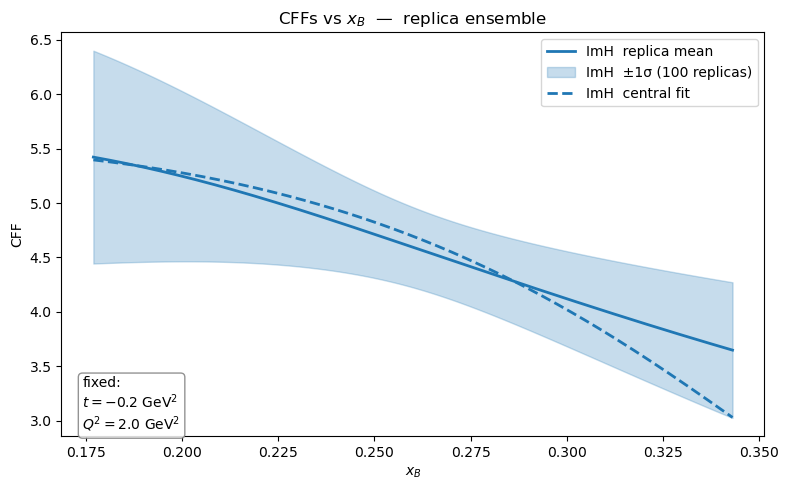

In [15]:
xB = np.linspace(0.177, 0.343, 300)  # to match the fitted range
t_fix, Q2_fix = -0.2, 2.0

central_curve  = cff_scan(xB, t_fix, Q2_fix, central_model)                          # [300, n_out]
replica_curves = np.stack([cff_scan(xB, t_fix, Q2_fix, m) for m in replica_models])  # [10, 300, n_out]
mean_curve = replica_curves.mean(axis=0)
std_curve  = replica_curves.std(axis=0)   # population std (ddof=0) -- matches getSigma()'s N convention

fig, ax = plt.subplots(figsize=(8, 5))
for k, name in enumerate(labels):
    color = f'C{k}'
    ax.plot(xB, mean_curve[:, k], lw=2, color=color, label=f'{name}  replica mean')
    ax.fill_between(xB, mean_curve[:, k] - std_curve[:, k], mean_curve[:, k] + std_curve[:, k],
                     color=color, alpha=0.25, label=f'{name}  ±1σ ({len(replica_models)} replicas)')
    ax.plot(xB, central_curve[:, k], lw=2, ls='--', color=color, label=f'{name}  central fit')
ax.set_xlabel(r'$x_B$')
ax.set_ylabel('CFF')
ax.set_title(r'CFFs vs $x_B$  —  replica ensemble')
ax.text(0.03, 0.15, f"fixed:\n$t = {t_fix}$ GeV$^2$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend()
plt.tight_layout()
plt.savefig('Plots/scan_cff_vs_xB_replica_farm.png', dpi=150, bbox_inches='tight')
plt.show()

### CFFs vs $-t$  (fixed $x_B=0.2$, $Q^2=2.2$ GeV$^2$) — replica mean ± σ band

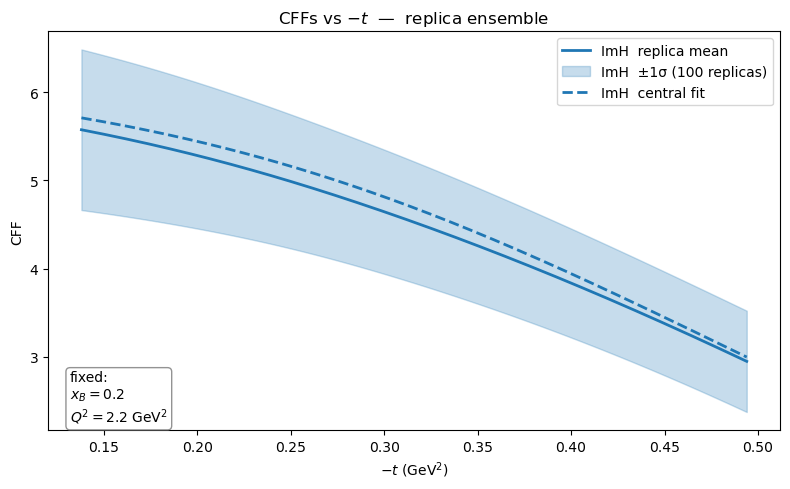

In [16]:
mt = np.linspace(0.138, 0.494, 300)  # -t = |t|, to match the fitted range
t  = -mt                             # physical (negative) t fed to the NN
xB_fix, Q2_fix = 0.2, 2.2

central_curve  = cff_scan(xB_fix, t, Q2_fix, central_model)
replica_curves = np.stack([cff_scan(xB_fix, t, Q2_fix, m) for m in replica_models])
mean_curve = replica_curves.mean(axis=0)
std_curve  = replica_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
for k, name in enumerate(labels):
    color = f'C{k}'
    ax.plot(mt, mean_curve[:, k], lw=2, color=color, label=f'{name}  replica mean')
    ax.fill_between(mt, mean_curve[:, k] - std_curve[:, k], mean_curve[:, k] + std_curve[:, k],
                     color=color, alpha=0.25, label=f'{name}  ±1σ ({len(replica_models)} replicas)')
    ax.plot(mt, central_curve[:, k], lw=2, ls='--', color=color, label=f'{name}  central fit')
ax.set_xlabel(r'$-t$ (GeV$^2$)')
ax.set_ylabel('CFF')
ax.set_title(r'CFFs vs $-t$  —  replica ensemble')
ax.text(0.03, 0.15, f"fixed:\n$x_B = {xB_fix}$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend()
plt.tight_layout()
plt.savefig('Plots/scan_cff_vs_mt_replica_farm.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparison with the Gepard NN ensemble fit (Farm, 100 replicas)

Loads the 100 Gepard replica nets trained on the same CLAS 2007 ALU dataset
(`NNALU` / `NeuralFitter_vectloss`, farm run) and overlays them against the
Partons replica ensemble + central fit computed above, on the same two CFF panels.

Reads the **portable JSON export** (`gepard_imh_replica_NN.json`, same
schema as `cff_model_replica_NN.json`) from the farm output directory --
so this section needs neither `torch` nor `gepard` to run: the same
`cff_forward`/`cff_scan` numpy functions defined above (for the Partons
side) read the Gepard nets too.

In [17]:
GEPARD_JSON_DIR = '/Users/marianav/Documents/Research/Analysis/GPD_studies/git/Gepard_jlabgithub_Mel2_latest_Sept2025_latest/ldrdgff/Partons_compare/Out_json/Farm/Json'

N_GEPARD_REPLICAS = 100
gepard_models = []
for i in range(N_GEPARD_REPLICAS):
    with open(f'{GEPARD_JSON_DIR}/gepard_imh_replica_{i:02d}.json') as f:
        gepard_models.append(json.load(f))

print(f'Loaded {len(gepard_models)} Gepard replica models (portable JSON -- no torch/gepard needed)')
print('Gepard arch:', gepard_models[0]['arch'], '| output_layer:', gepard_models[0]['output_layer'])

Loaded 100 Gepard replica models (portable JSON -- no torch/gepard needed)
Gepard arch: {'in': 3, 'hidden': 6, 'out': 1, 'activation': 'tanh'} | output_layer: ['ImH']


### $\mathrm{Im}\,\mathcal{H}(x_B)$ at fixed $t=-0.2$, $Q^2=2$ — Gepard vs Partons

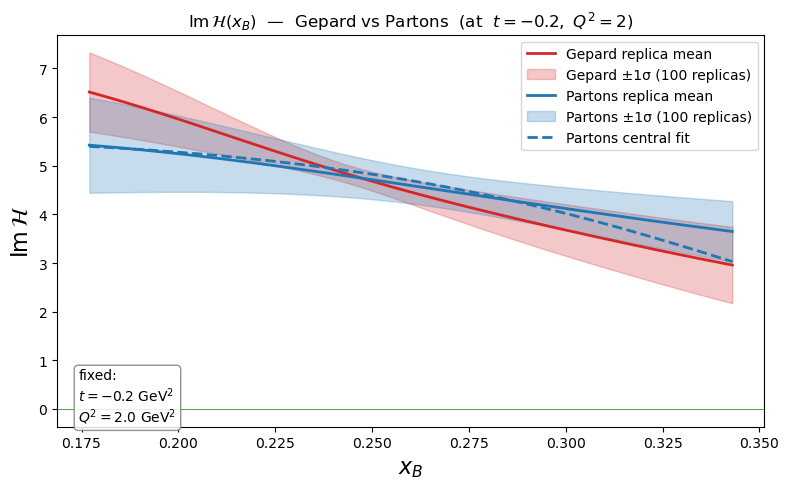

In [18]:
xvals = np.linspace(0.177, 0.343, 300)
t_fix, Q2_fix = -0.2, 2.0

central_curve  = cff_scan(xvals, t_fix, Q2_fix, central_model)[:, 0]
partons_curves = np.stack([cff_scan(xvals, t_fix, Q2_fix, m)[:, 0] for m in replica_models])
partons_mean = partons_curves.mean(axis=0)
partons_std  = partons_curves.std(axis=0)

gepard_curves = np.stack([cff_scan(xvals, t_fix, Q2_fix, m)[:, 0] for m in gepard_models])
gepard_mean = gepard_curves.mean(axis=0)
gepard_std  = gepard_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

# --- Gepard ensemble: mean line + std band ---
ax.plot(xvals, gepard_mean, lw=2, color='C3', label='Gepard replica mean')
ax.fill_between(xvals, gepard_mean - gepard_std, gepard_mean + gepard_std,
                 color='C3', alpha=0.25, label=f'Gepard ±1σ ({len(gepard_models)} replicas)')

# --- Partons ensemble: mean line + std band + central fit ---
ax.plot(xvals, partons_mean, lw=2, color='C0', label='Partons replica mean')
ax.fill_between(xvals, partons_mean - partons_std, partons_mean + partons_std,
                 color='C0', alpha=0.25, label=f'Partons ±1σ ({len(replica_models)} replicas)')
ax.plot(xvals, central_curve, lw=2, ls='--', color='C0', label='Partons central fit')

ax.set_xlabel(r'$x_B$', fontsize=16)
ax.set_ylabel(r'$\mathrm{Im}\,\mathcal{H}$', fontsize=16)
ax.axhline(y=0, lw=0.5, color='g')
ax.set_title(r'$\mathrm{Im}\,\mathcal{H}(x_B)$  —  Gepard vs Partons  (at  $t=-0.2,\ Q^2=2$)')
ax.text(0.03, 0.15, f"fixed:\n$t = {t_fix}$ GeV$^2$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend(loc='best')
plt.tight_layout()
plt.savefig('Plots/scan_cff_vs_xB_gepard_vs_partons_farm.png', dpi=150, bbox_inches='tight')
plt.show()

### $\mathrm{Im}\,\mathcal{H}(-t)$ at fixed $x_B=0.2$, $Q^2=2.2$ — Gepard vs Partons

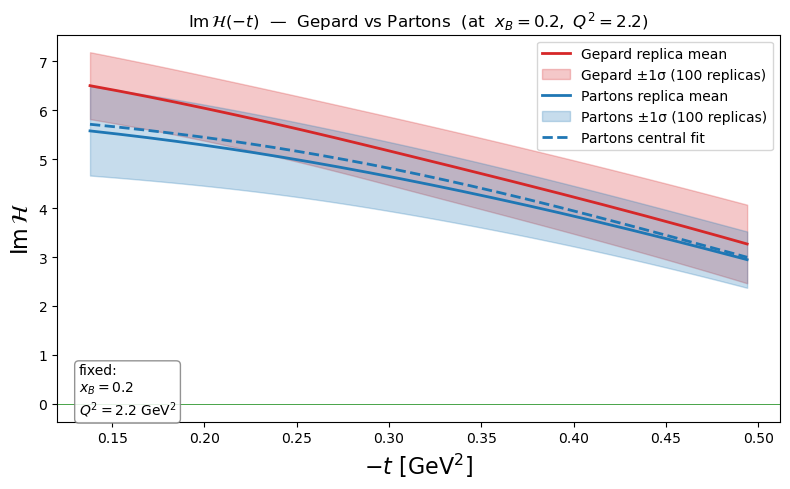

In [19]:
mt = np.linspace(0.138, 0.494, 300)  # -t = |t|
t  = -mt                             # physical (negative) t fed to the NN
xB_fix, Q2_fix = 0.2, 2.2

central_curve  = cff_scan(xB_fix, t, Q2_fix, central_model)[:, 0]
partons_curves = np.stack([cff_scan(xB_fix, t, Q2_fix, m)[:, 0] for m in replica_models])
partons_mean = partons_curves.mean(axis=0)
partons_std  = partons_curves.std(axis=0)

gepard_curves = np.stack([cff_scan(xB_fix, t, Q2_fix, m)[:, 0] for m in gepard_models])
gepard_mean = gepard_curves.mean(axis=0)
gepard_std  = gepard_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

# --- Gepard ensemble: mean line + std band ---
ax.plot(mt, gepard_mean, lw=2, color='C3', label='Gepard replica mean')
ax.fill_between(mt, gepard_mean - gepard_std, gepard_mean + gepard_std,
                 color='C3', alpha=0.25, label=f'Gepard ±1σ ({len(gepard_models)} replicas)')

# --- Partons ensemble: mean line + std band + central fit ---
ax.plot(mt, partons_mean, lw=2, color='C0', label='Partons replica mean')
ax.fill_between(mt, partons_mean - partons_std, partons_mean + partons_std,
                 color='C0', alpha=0.25, label=f'Partons ±1σ ({len(replica_models)} replicas)')
ax.plot(mt, central_curve, lw=2, ls='--', color='C0', label='Partons central fit')

ax.set_xlabel(r'$-t\ [{\rm GeV}^2]$', fontsize=16)
ax.set_ylabel(r'$\mathrm{Im}\,\mathcal{H}$', fontsize=16)
ax.axhline(y=0, lw=0.5, color='g')
ax.set_title(r'$\mathrm{Im}\,\mathcal{H}(-t)$  —  Gepard vs Partons  (at  $x_B=0.2,\ Q^2=2.2$)')
ax.text(0.03, 0.15, f"fixed:\n$x_B = {xB_fix}$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend(loc='best')
plt.tight_layout()
plt.savefig('Plots/scan_cff_vs_mt_gepard_vs_partons_farm.png', dpi=150, bbox_inches='tight')
plt.show()

## Gepard vs Partons — bands only (no central fit overlay)

Same two panels, but showing only the two ensemble mean ± σ bands (Gepard's
10-net ensemble vs. the Partons 10-replica ensemble) with the Partons
central-fit curve omitted, for a cleaner ensemble-to-ensemble comparison.

### $\mathrm{Im}\,\mathcal{H}(x_B)$ at fixed $t=-0.2$, $Q^2=2$ — Gepard vs Partons bands

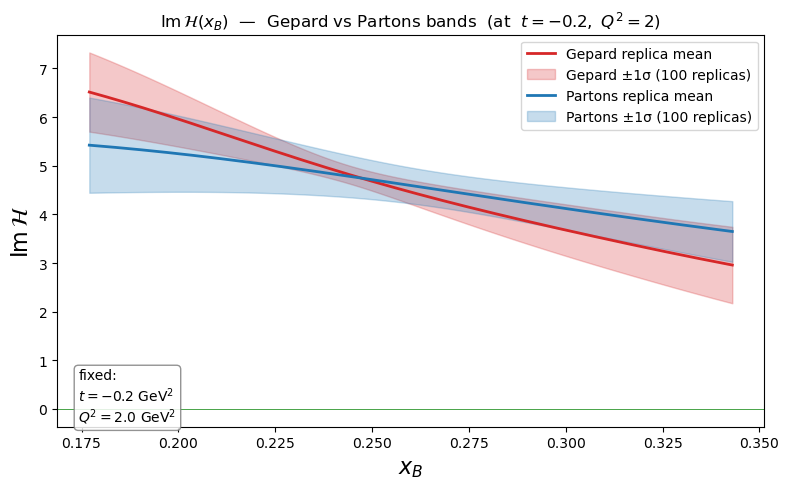

In [20]:
xvals = np.linspace(0.177, 0.343, 300)
t_fix, Q2_fix = -0.2, 2.0

partons_curves = np.stack([cff_scan(xvals, t_fix, Q2_fix, m)[:, 0] for m in replica_models])
partons_mean = partons_curves.mean(axis=0)
partons_std  = partons_curves.std(axis=0)

gepard_curves = np.stack([cff_scan(xvals, t_fix, Q2_fix, m)[:, 0] for m in gepard_models])
gepard_mean = gepard_curves.mean(axis=0)
gepard_std  = gepard_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

# --- Gepard ensemble: mean line + std band ---
ax.plot(xvals, gepard_mean, lw=2, color='C3', label='Gepard replica mean')
ax.fill_between(xvals, gepard_mean - gepard_std, gepard_mean + gepard_std,
                 color='C3', alpha=0.25, label=f'Gepard ±1σ ({len(gepard_models)} replicas)')

# --- Partons ensemble: mean line + std band (no central fit) ---
ax.plot(xvals, partons_mean, lw=2, color='C0', label='Partons replica mean')
ax.fill_between(xvals, partons_mean - partons_std, partons_mean + partons_std,
                 color='C0', alpha=0.25, label=f'Partons ±1σ ({len(replica_models)} replicas)')

ax.set_xlabel(r'$x_B$', fontsize=16)
ax.set_ylabel(r'$\mathrm{Im}\,\mathcal{H}$', fontsize=16)
ax.axhline(y=0, lw=0.5, color='g')
ax.set_title(r'$\mathrm{Im}\,\mathcal{H}(x_B)$  —  Gepard vs Partons bands  (at  $t=-0.2,\ Q^2=2$)')
ax.text(0.03, 0.15, f"fixed:\n$t = {t_fix}$ GeV$^2$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend(loc='best')
plt.tight_layout()
plt.savefig('Plots/scan_cff_vs_xB_gepard_vs_partons_bands_only_farm.png', dpi=150, bbox_inches='tight')
plt.show()

### $\mathrm{Im}\,\mathcal{H}(-t)$ at fixed $x_B=0.2$, $Q^2=2.2$ — Gepard vs Partons bands

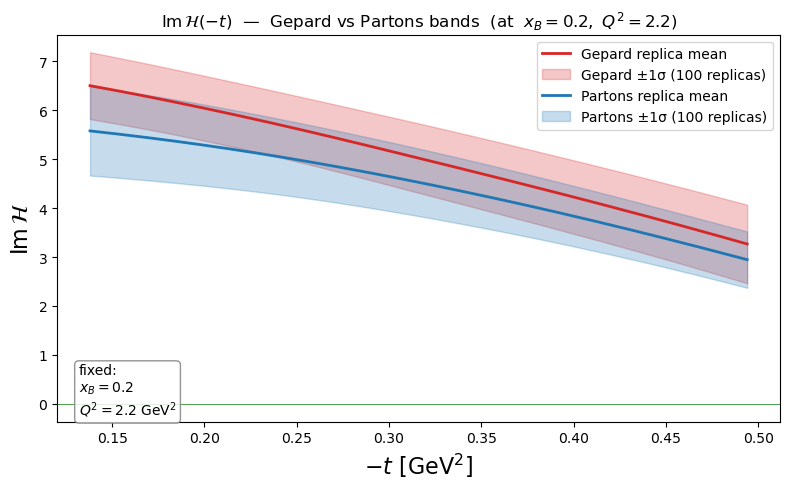

In [21]:
mt = np.linspace(0.138, 0.494, 300)  # -t = |t|
t  = -mt                             # physical (negative) t fed to the NN
xB_fix, Q2_fix = 0.2, 2.2

partons_curves = np.stack([cff_scan(xB_fix, t, Q2_fix, m)[:, 0] for m in replica_models])
partons_mean = partons_curves.mean(axis=0)
partons_std  = partons_curves.std(axis=0)

gepard_curves = np.stack([cff_scan(xB_fix, t, Q2_fix, m)[:, 0] for m in gepard_models])
gepard_mean = gepard_curves.mean(axis=0)
gepard_std  = gepard_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

# --- Gepard ensemble: mean line + std band ---
ax.plot(mt, gepard_mean, lw=2, color='C3', label='Gepard replica mean')
ax.fill_between(mt, gepard_mean - gepard_std, gepard_mean + gepard_std,
                 color='C3', alpha=0.25, label=f'Gepard ±1σ ({len(gepard_models)} replicas)')

# --- Partons ensemble: mean line + std band (no central fit) ---
ax.plot(mt, partons_mean, lw=2, color='C0', label='Partons replica mean')
ax.fill_between(mt, partons_mean - partons_std, partons_mean + partons_std,
                 color='C0', alpha=0.25, label=f'Partons ±1σ ({len(replica_models)} replicas)')

ax.set_xlabel(r'$-t\ [{\rm GeV}^2]$', fontsize=16)
ax.set_ylabel(r'$\mathrm{Im}\,\mathcal{H}$', fontsize=16)
ax.axhline(y=0, lw=0.5, color='g')
ax.set_title(r'$\mathrm{Im}\,\mathcal{H}(-t)$  —  Gepard vs Partons bands  (at  $x_B=0.2,\ Q^2=2.2$)')
ax.text(0.03, 0.15, f"fixed:\n$x_B = {xB_fix}$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend(loc='best')
plt.tight_layout()
plt.savefig('Plots/scan_cff_vs_mt_gepard_vs_partons_bands_only_farm.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparison with Gepard BMK model (Farm, 100 replicas)

The Gepard ensemble above uses the BM10ex process model (`NeuralFitter_vectloss`
default). This section loads a second Gepard ensemble trained with the **BMK**
process model instead (`gepard_imh_replica_BMK_NN.json`, same farm run, same
CLAS 2007 ALU dataset, same architecture/hyperparameters), and overlays all
three ensembles: Partons, Gepard BM10ex, Gepard BMK.

In [22]:
GEPARD_BMK_JSON_DIR = GEPARD_JSON_DIR  # same Farm/Json directory, _BMK-suffixed files

N_GEPARD_BMK_REPLICAS = 100
gepard_bmk_models = []
for i in range(N_GEPARD_BMK_REPLICAS):
    with open(f'{GEPARD_BMK_JSON_DIR}/gepard_imh_replica_BMK_{i:02d}.json') as f:
        gepard_bmk_models.append(json.load(f))

for i, m in enumerate(gepard_bmk_models):
    assert m['output_layer'] == labels, f'BMK model {i:02d}: output_layer mismatch'
    assert m['arch'] == central_model['arch'], f'BMK model {i:02d}: arch mismatch'

print(f'Loaded {len(gepard_bmk_models)} Gepard BMK replica models')
print('Gepard BMK arch:', gepard_bmk_models[0]['arch'], '| output_layer:', gepard_bmk_models[0]['output_layer'])

Loaded 100 Gepard BMK replica models
Gepard BMK arch: {'in': 3, 'hidden': 6, 'out': 1, 'activation': 'tanh'} | output_layer: ['ImH']


### $\mathrm{Im}\,\mathcal{H}(x_B)$ at fixed $t=-0.2$, $Q^2=2$ — Gepard BMK vs Partons

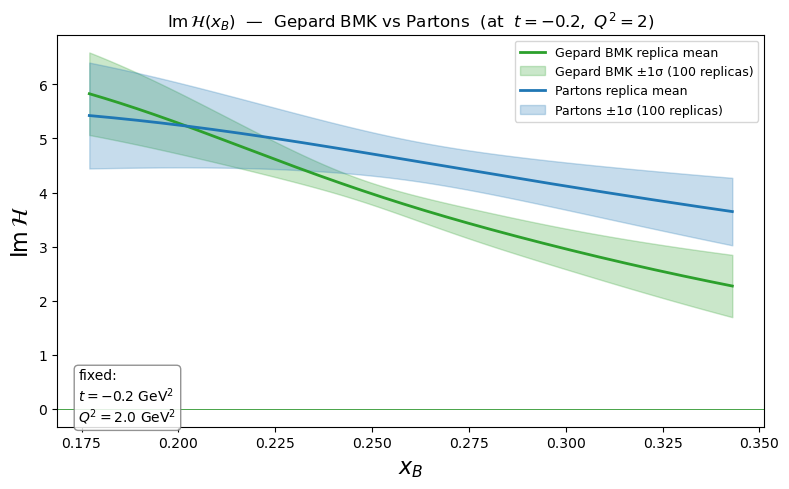

In [23]:
xvals = np.linspace(0.177, 0.343, 300)
t_fix, Q2_fix = -0.2, 2.0

central_curve  = cff_scan(xvals, t_fix, Q2_fix, central_model)[:, 0]
partons_curves = np.stack([cff_scan(xvals, t_fix, Q2_fix, m)[:, 0] for m in replica_models])
partons_mean = partons_curves.mean(axis=0)
partons_std  = partons_curves.std(axis=0)

gepard_bmk_curves = np.stack([cff_scan(xvals, t_fix, Q2_fix, m)[:, 0] for m in gepard_bmk_models])
gepard_bmk_mean = gepard_bmk_curves.mean(axis=0)
gepard_bmk_std  = gepard_bmk_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(xvals, gepard_bmk_mean, lw=2, color='C2', label='Gepard BMK replica mean')
ax.fill_between(xvals, gepard_bmk_mean - gepard_bmk_std, gepard_bmk_mean + gepard_bmk_std,
                 color='C2', alpha=0.25, label=f'Gepard BMK ±1σ ({len(gepard_bmk_models)} replicas)')

ax.plot(xvals, partons_mean, lw=2, color='C0', label='Partons replica mean')
ax.fill_between(xvals, partons_mean - partons_std, partons_mean + partons_std,
                 color='C0', alpha=0.25, label=f'Partons ±1σ ({len(replica_models)} replicas)')
#ax.plot(xvals, central_curve, lw=2, ls='--', color='C0', label='Partons central fit')

ax.set_xlabel(r'$x_B$', fontsize=16)
ax.set_ylabel(r'$\mathrm{Im}\,\mathcal{H}$', fontsize=16)
ax.axhline(y=0, lw=0.5, color='g')
ax.set_title(r'$\mathrm{Im}\,\mathcal{H}(x_B)$  —  Gepard BMK vs Partons  (at  $t=-0.2,\ Q^2=2$)')
ax.text(0.03, 0.15, f"fixed:\n$t = {t_fix}$ GeV$^2$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('Plots/scan_cff_vs_xB_gepard_BMK_vs_partons_farm.png', dpi=150, bbox_inches='tight')
plt.show()

### $\mathrm{Im}\,\mathcal{H}(-t)$ at fixed $x_B=0.2$, $Q^2=2.2$ — Gepard BMK vs Partons

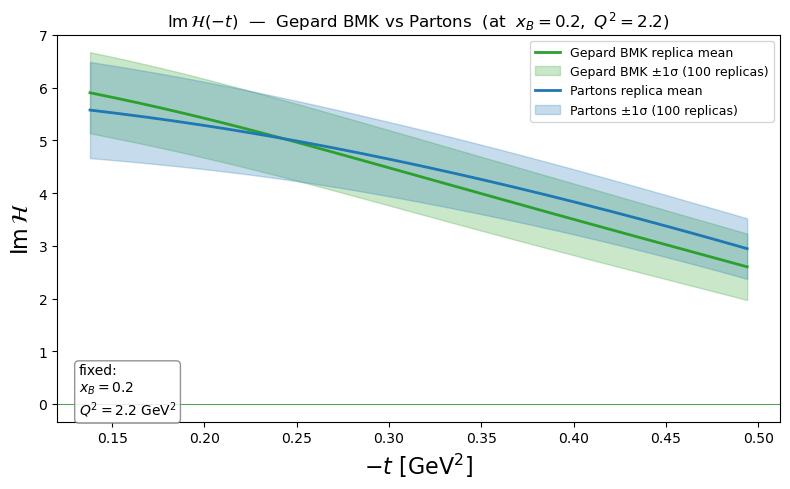

In [27]:
mt = np.linspace(0.138, 0.494, 300)  # -t = |t|
t  = -mt                             # physical (negative) t fed to the NN
xB_fix, Q2_fix = 0.2, 2.2

central_curve  = cff_scan(xB_fix, t, Q2_fix, central_model)[:, 0]
partons_curves = np.stack([cff_scan(xB_fix, t, Q2_fix, m)[:, 0] for m in replica_models])
partons_mean = partons_curves.mean(axis=0)
partons_std  = partons_curves.std(axis=0)

gepard_bmk_curves = np.stack([cff_scan(xB_fix, t, Q2_fix, m)[:, 0] for m in gepard_bmk_models])
gepard_bmk_mean = gepard_bmk_curves.mean(axis=0)
gepard_bmk_std  = gepard_bmk_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(mt, gepard_bmk_mean, lw=2, color='C2', label='Gepard BMK replica mean')
ax.fill_between(mt, gepard_bmk_mean - gepard_bmk_std, gepard_bmk_mean + gepard_bmk_std,
                 color='C2', alpha=0.25, label=f'Gepard BMK ±1σ ({len(gepard_bmk_models)} replicas)')

ax.plot(mt, partons_mean, lw=2, color='C0', label='Partons replica mean')
ax.fill_between(mt, partons_mean - partons_std, partons_mean + partons_std,
                 color='C0', alpha=0.25, label=f'Partons ±1σ ({len(replica_models)} replicas)')
#ax.plot(mt, central_curve, lw=2, ls='--', color='C0', label='Partons central fit')

ax.set_xlabel(r'$-t\ [{\rm GeV}^2]$', fontsize=16)
ax.set_ylabel(r'$\mathrm{Im}\,\mathcal{H}$', fontsize=16)
ax.axhline(y=0, lw=0.5, color='g')
ax.set_title(r'$\mathrm{Im}\,\mathcal{H}(-t)$  —  Gepard BMK vs Partons  (at  $x_B=0.2,\ Q^2=2.2$)')
ax.text(0.03, 0.15, f"fixed:\n$x_B = {xB_fix}$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('Plots/scan_cff_vs_mt_gepard_BMK_vs_partons_farm.png', dpi=150, bbox_inches='tight')
plt.show()

### $\mathrm{Im}\,\mathcal{H}(x_B)$ at fixed $t=-0.2$, $Q^2=2$ — Gepard BMK vs BM10ex

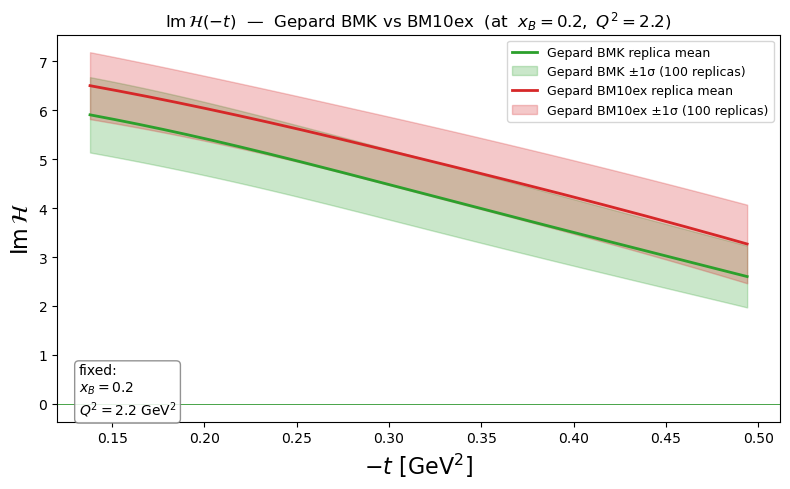

In [25]:
mt = np.linspace(0.138, 0.494, 300)  # -t = |t|
t  = -mt                             # physical (negative) t fed to the NN
xB_fix, Q2_fix = 0.2, 2.2

gepard_curves = np.stack([cff_scan(xB_fix, t, Q2_fix, m)[:, 0] for m in gepard_models])
gepard_mean = gepard_curves.mean(axis=0)
gepard_std  = gepard_curves.std(axis=0)

gepard_bmk_curves = np.stack([cff_scan(xB_fix, t, Q2_fix, m)[:, 0] for m in gepard_bmk_models])
gepard_bmk_mean = gepard_bmk_curves.mean(axis=0)
gepard_bmk_std  = gepard_bmk_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(mt, gepard_bmk_mean, lw=2, color='C2', label='Gepard BMK replica mean')
ax.fill_between(mt, gepard_bmk_mean - gepard_bmk_std, gepard_bmk_mean + gepard_bmk_std,
                 color='C2', alpha=0.25, label=f'Gepard BMK ±1σ ({len(gepard_bmk_models)} replicas)')

ax.plot(mt, gepard_mean, lw=2, color='C3', label='Gepard BM10ex replica mean')
ax.fill_between(mt, gepard_mean - gepard_std, gepard_mean + gepard_std,
                 color='C3', alpha=0.25, label=f'Gepard BM10ex ±1σ ({len(gepard_models)} replicas)')

ax.set_xlabel(r'$-t\ [{\rm GeV}^2]$', fontsize=16)
ax.set_ylabel(r'$\mathrm{Im}\,\mathcal{H}$', fontsize=16)
ax.axhline(y=0, lw=0.5, color='g')
ax.set_title(r'$\mathrm{Im}\,\mathcal{H}(-t)$  —  Gepard BMK vs BM10ex  (at  $x_B=0.2,\ Q^2=2.2$)')
ax.text(0.03, 0.15, f"fixed:\n$x_B = {xB_fix}$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('Plots/scan_cff_vs_mt_gepard_BMK_vs_BM10ex_farm.png', dpi=150, bbox_inches='tight')
plt.show()

### $\mathrm{Im}\,\mathcal{H}(-t)$ at fixed $x_B=0.2$, $Q^2=2.2$ — Gepard BMK vs BM10ex

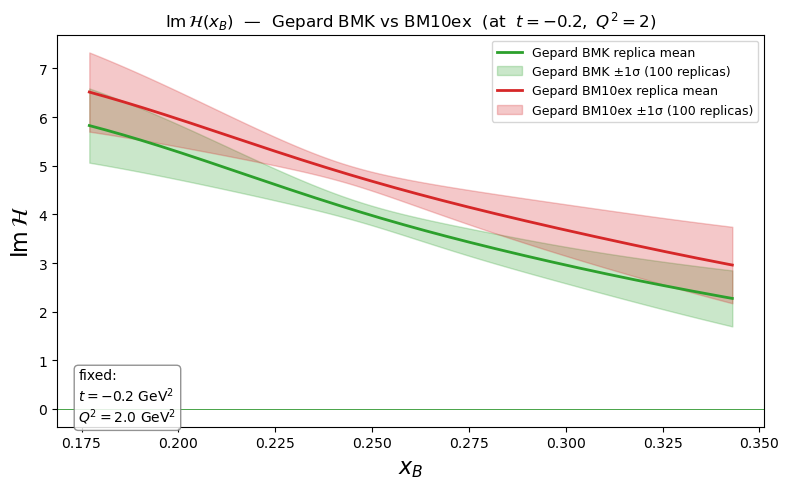

In [26]:
xvals = np.linspace(0.177, 0.343, 300)
t_fix, Q2_fix = -0.2, 2.0

gepard_curves = np.stack([cff_scan(xvals, t_fix, Q2_fix, m)[:, 0] for m in gepard_models])
gepard_mean = gepard_curves.mean(axis=0)
gepard_std  = gepard_curves.std(axis=0)

gepard_bmk_curves = np.stack([cff_scan(xvals, t_fix, Q2_fix, m)[:, 0] for m in gepard_bmk_models])
gepard_bmk_mean = gepard_bmk_curves.mean(axis=0)
gepard_bmk_std  = gepard_bmk_curves.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(xvals, gepard_bmk_mean, lw=2, color='C2', label='Gepard BMK replica mean')
ax.fill_between(xvals, gepard_bmk_mean - gepard_bmk_std, gepard_bmk_mean + gepard_bmk_std,
                 color='C2', alpha=0.25, label=f'Gepard BMK ±1σ ({len(gepard_bmk_models)} replicas)')

ax.plot(xvals, gepard_mean, lw=2, color='C3', label='Gepard BM10ex replica mean')
ax.fill_between(xvals, gepard_mean - gepard_std, gepard_mean + gepard_std,
                 color='C3', alpha=0.25, label=f'Gepard BM10ex ±1σ ({len(gepard_models)} replicas)')

ax.set_xlabel(r'$x_B$', fontsize=16)
ax.set_ylabel(r'$\mathrm{Im}\,\mathcal{H}$', fontsize=16)
ax.axhline(y=0, lw=0.5, color='g')
ax.set_title(r'$\mathrm{Im}\,\mathcal{H}(x_B)$  —  Gepard BMK vs BM10ex  (at  $t=-0.2,\ Q^2=2$)')
ax.text(0.03, 0.15, f"fixed:\n$t = {t_fix}$ GeV$^2$\n$Q^2 = {Q2_fix}$ GeV$^2$",
        transform=ax.transAxes, va='top', ha='left',
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig('Plots/scan_cff_vs_xB_gepard_BMK_vs_BM10ex_farm.png', dpi=150, bbox_inches='tight')
plt.show()